In [13]:
import sys
import os
# Adiciona a pasta raiz do projeto (onde está a pasta src) ao sys.path
sys.path.append(os.path.abspath(os.path.join("..")))
import pandas as pd
from src.visualization.static_plot import *

In [41]:
tbl_simulacao = pd.read_csv('../data/simulation/sim_2025-09-30_02-10-43.csv', sep=',')

In [42]:
tbl_simulacao.describe()

,previsao_min,tempo_real_min,tempo_corrigido_min,delivery_distance,tempo_coleta,Agent_Rating,is_grocery,jam_or_high_traffic,is_sunny_weather,tempo_criacao_sim,tempo_conclusao_sim,is_otd_corrigido
count,4289.000000,4289.000000,4289.000000,4289.000000,4289.000000,4289.000000,4289.000000,4289.000000,4289.000000,4289.000000,4289.000000,4289.000000
mean,125.673291,115.619798,98.129309,9.617354,10.114246,4.694602,0.000933,0.691770,0.201912,5634.055427,5742.298981,0.757986
std,30.084106,32.046273,30.306533,5.548758,4.091822,0.198775,0.030528,0.461816,0.401474,3669.902170,3670.511436,0.428353
min,47.470069,21.710903,0.000000,0.000000,5.000000,3.886543,0.000000,0.000000,0.000000,4.174683,74.741260,0.000000
25%,103.919656,91.549202,75.918387,5.052750,5.000000,4.563776,0.000000,0.000000,0.000000,2062.447219,2165.752241,1.000000
50%,115.640746,108.051700,90.859233,8.799050,10.000000,4.690722,0.000000,1.000000,0.000000,5344.402237,5450.574195,1.000000
75%,152.186092,138.936033,118.903830,14.426577,15.000000,4.831427,0.000000,1.000000,0.000000,8427.644523,8541.321117,1.000000
max,216.677965,224.640273,211.261978,24.545246,15.000000,5.467553,1.000000,1.000000,1.000000,11545.471235,11732.625502,1.000000


In [43]:
tbl_simulacao['res'] = tbl_simulacao['tempo_real_min'] - tbl_simulacao['previsao_min']

In [44]:
tbl_simulacao['res_corr'] = tbl_simulacao['tempo_real_min'] - tbl_simulacao['tempo_corrigido_min']

In [45]:
tbl_simulacao.query("tempo_real_min<120 and is_grocery==0 and res<-10")

,id_pedido,previsao_min,tempo_real_min,tempo_corrigido_min,delivery_distance,tempo_coleta,Agent_Rating,Vehicle,Weather,Traffic,...,weekend,is_grocery,jam_or_high_traffic,is_sunny_weather,tempo_criacao_sim,tempo_conclusao_sim,decisao,is_otd_corrigido,res,res_corr
0,pedido_4.1746831265637345_1,92.596480,75.566577,60.566577,20.001658,10,4.515129,Scooter,Sunny,Medium,...,False,0,0,1,4.174683,74.741260,Intervenção_Médio_Risco,1,-17.029903,15.0
1,pedido_7.4101644479337345_4,109.254382,92.898872,62.898872,14.342145,15,4.817569,Scooter,Sandstorms,High,...,False,0,1,0,7.410164,85.309036,Intervencao_Risco_Extremo,1,-16.355510,30.0
2,pedido_15.497202650708434_10,105.769052,90.813000,75.813000,17.660646,10,4.861401,Moto,Sandstorms,Medium,...,True,0,0,0,15.497203,101.310203,Intervenção_Médio_Risco,1,-14.956051,15.0
7,pedido_28.741994357137948_16,116.466735,100.400968,70.400968,19.308997,15,4.703479,Moto,Foggy,High,...,True,0,1,0,28.741994,114.142962,Intervencao_Risco_Extremo,1,-16.065767,30.0
9,pedido_42.706249456618345_19,126.715906,96.959229,66.959229,18.407532,10,4.956665,Moto,Foggy,High,...,True,0,1,0,42.706249,119.665479,Intervencao_Risco_Extremo,1,-29.756677,30.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4262,pedido_11520.571710248252_959,107.590771,87.288188,72.288188,3.040031,15,4.711383,Moto,Windy,High,...,False,0,1,0,11520.571710,11607.859898,Intervenção_Alto_Risco,1,-20.302583,15.0
4265,pedido_11544.639396971128_974,109.127339,86.688883,71.688883,5.714271,5,5.249888,Moto,Sandstorms,Jam,...,False,0,1,0,11544.639397,11621.328280,Intervenção_Alto_Risco,1,-22.438456,15.0
4268,pedido_11539.89253467067_971,109.513030,89.652208,74.652208,7.789157,10,4.785828,Moto,Windy,High,...,False,0,1,0,11539.892535,11624.544743,Intervenção_Alto_Risco,1,-19.860822,15.0
4270,pedido_11545.471235060486_976,109.620404,90.012949,75.012949,1.483892,5,4.684864,Moto,Foggy,Jam,...,False,0,1,0,11545.471235,11625.484184,Intervenção_Alto_Risco,1,-19.607455,15.0


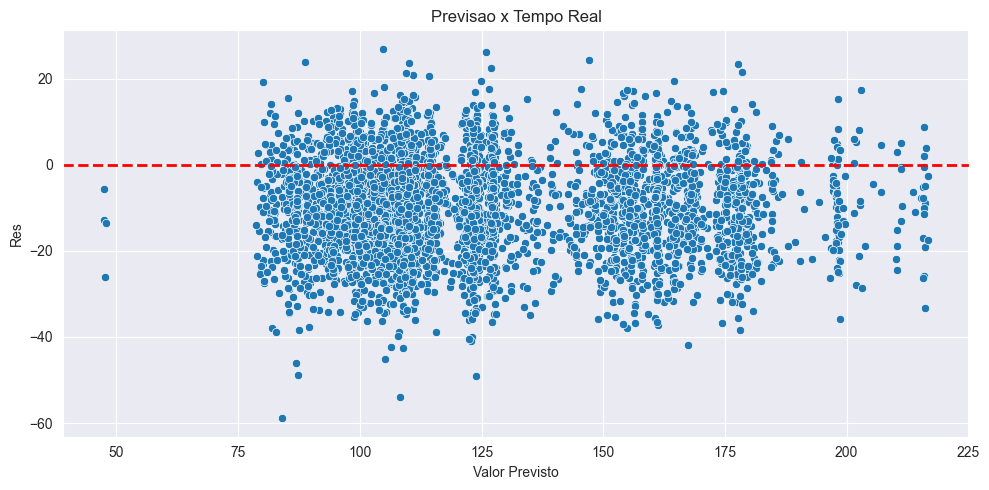

In [46]:
grafico_dispersao(df=tbl_simulacao, y=tbl_simulacao['res'],
                          x=tbl_simulacao['previsao_min'],
                          titulo='Previsao x Tempo Real', ylabel='Res', xlabel='Valor Previsto',res=True)

<Axes: >

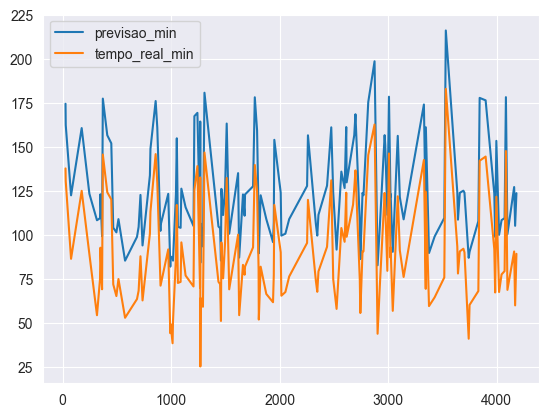

In [47]:
tbl_simulacao[tbl_simulacao.res<-30][['previsao_min','tempo_real_min',]].plot(kind='line')

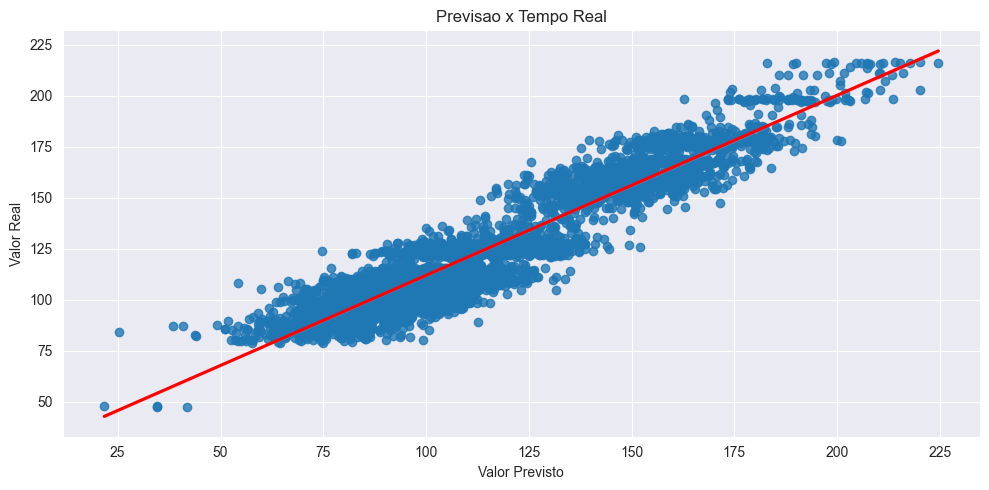

In [48]:
grafico_dispersao(df=tbl_simulacao, y=tbl_simulacao['previsao_min'],
                          x=tbl_simulacao['tempo_real_min'],
                          titulo='Previsao x Tempo Real', ylabel='Valor Real', xlabel='Valor Previsto',regr=True)

<Axes: >

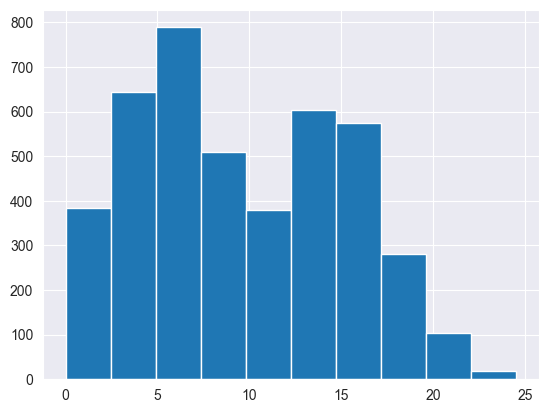

In [49]:
tbl_simulacao.delivery_distance.hist()

In [50]:
otd_simulacao = (tbl_simulacao['tempo_real_min'] <= 120).mean()
otd_simulacao

np.float64(0.6288179062718583)

In [51]:
otd_corrigido = (tbl_simulacao['tempo_corrigido_min'] <= 120).mean()
otd_corrigido

np.float64(0.7579855444159478)

In [52]:
tbl_simulacao[tbl_simulacao.tempo_corrigido_min<=120].shape[0]/tbl_simulacao.shape[0]

0.7579855444159478